In [1]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from HybridKANSRF import HybridColorKAN



In [2]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

In [3]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [4]:
#Normalizing the image
max_val = np.max(image)
normalized_image = image.astype(np.float32) / max_val

In [5]:

image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


In [6]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [7]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

In [8]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)


model = HybridColorKAN(
    no_of_bands=no_of_bands,
    number_of_primitives=number_of_primitives,
    output_classes=output_classes,

    # RBF bases used to generate the smooth wavelength SRF
    wavelength_num_grids=12,

    # Original FastKAN intensity RBF bases
    intensity_num_grids=8,

    # First experiment:
    # signed smooth wavelength envelope
    nonnegative_srf=False,

    # Keep original FastKAN base path
    use_base_update=True,

    # Same initialization scale as original FastKAN
    spline_weight_init_scale=0.1
).to(device)

print(model)

Using device: cpu
HybridColorKAN(
  (primitives): ModuleList(
    (0-2): 3 x HybridSpectralPrimitive(
      (srf_generator): WavelengthSRFGenerator(
        (wavelength_rbf): GaussianRBF()
      )
      (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
      (intensity_rbf): GaussianRBF()
      (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
      (base_linear): Linear(in_features=66, out_features=1, bias=True)
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)


In [9]:
print(model)

HybridColorKAN(
  (primitives): ModuleList(
    (0-2): 3 x HybridSpectralPrimitive(
      (srf_generator): WavelengthSRFGenerator(
        (wavelength_rbf): GaussianRBF()
      )
      (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
      (intensity_rbf): GaussianRBF()
      (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
      (base_linear): Linear(in_features=66, out_features=1, bias=True)
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)


In [10]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

optimizer = torch.optim.Adam(
    model.parameters(),)

criterion = nn.CrossEntropyLoss()

x_tensor = torch.tensor( x,dtype=torch.float32)

y_tensor = torch.tensor( y,dtype=torch.long)

batch_size = 32

dataset = TensorDataset(x_tensor,y_tensor)

train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output,batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 1.1081 | Accuracy: 0.6184
Epoch [2/30] | Loss: 0.7205 | Accuracy: 0.7348
Epoch [3/30] | Loss: 0.6614 | Accuracy: 0.7613
Epoch [4/30] | Loss: 0.6322 | Accuracy: 0.7761
Epoch [5/30] | Loss: 0.6116 | Accuracy: 0.7864
Epoch [6/30] | Loss: 0.5961 | Accuracy: 0.7918
Epoch [7/30] | Loss: 0.5822 | Accuracy: 0.7972
Epoch [8/30] | Loss: 0.5715 | Accuracy: 0.8007
Epoch [9/30] | Loss: 0.5626 | Accuracy: 0.8031
Epoch [10/30] | Loss: 0.5536 | Accuracy: 0.8062
Epoch [11/30] | Loss: 0.5464 | Accuracy: 0.8089
Epoch [12/30] | Loss: 0.5408 | Accuracy: 0.8098
Epoch [13/30] | Loss: 0.5343 | Accuracy: 0.8112
Epoch [14/30] | Loss: 0.5296 | Accuracy: 0.8120
Epoch [15/30] | Loss: 0.5246 | Accuracy: 0.8142
Epoch [16/30] | Loss: 0.5202 | Accuracy: 0.8147
Epoch [17/30] | Loss: 0.5160 | Accuracy: 0.8169
Epoch [18/30] | Loss: 0.5129 | Accuracy: 0.8156
Epoch [19/30] | Loss: 0.5085 | Accuracy: 0.8190
Epoch [20/30] | Loss: 0.5053 | Accuracy: 0.8191
Epoch [21/30] | Loss: 0.5029 | 

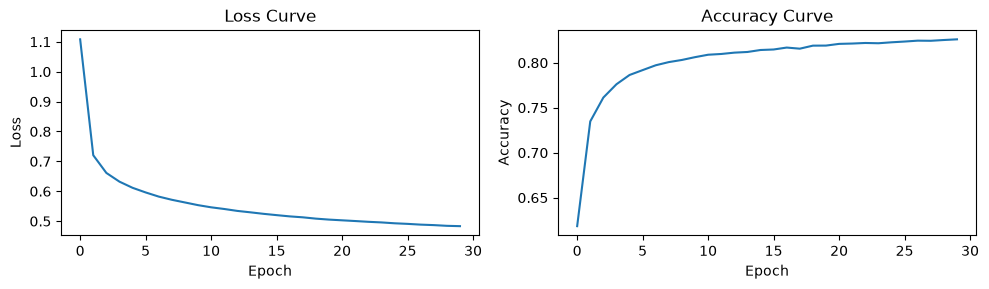

In [11]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

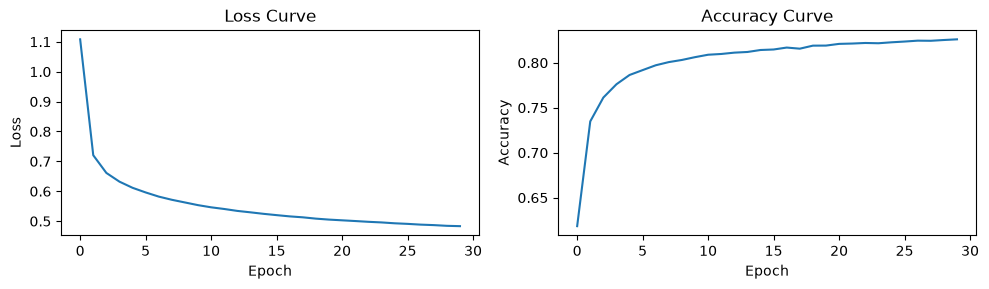

In [12]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [13]:
wavelength = np.linspace(430, 860, no_of_bands) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


Primitive 1 SRF shape: (66,)


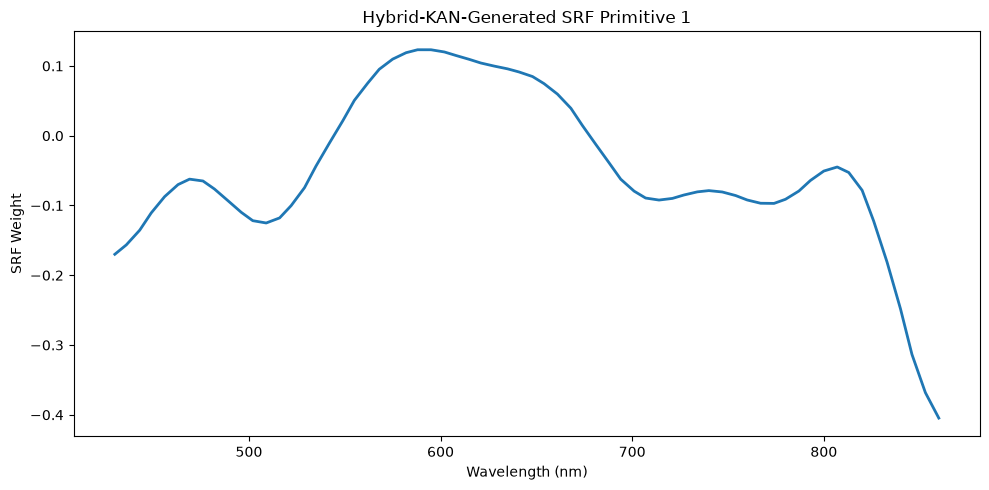

Primitive 2 SRF shape: (66,)


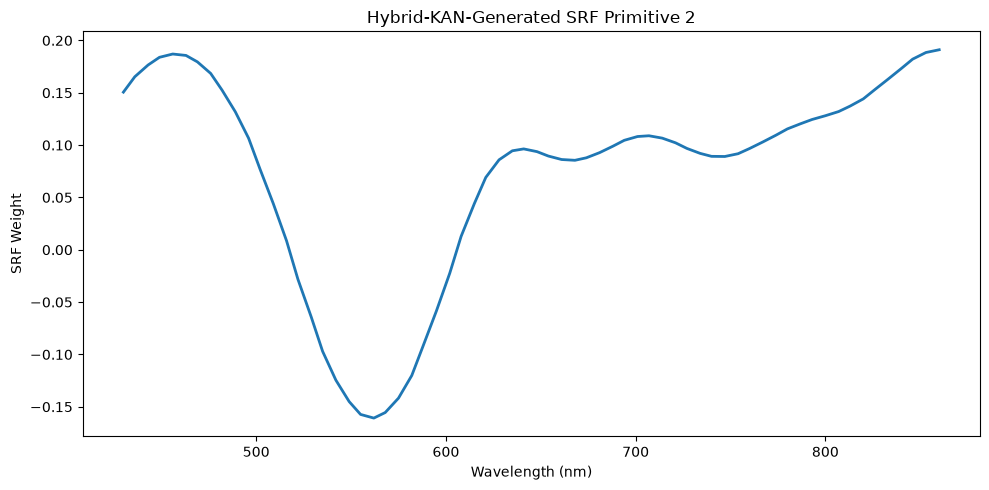

Primitive 3 SRF shape: (66,)


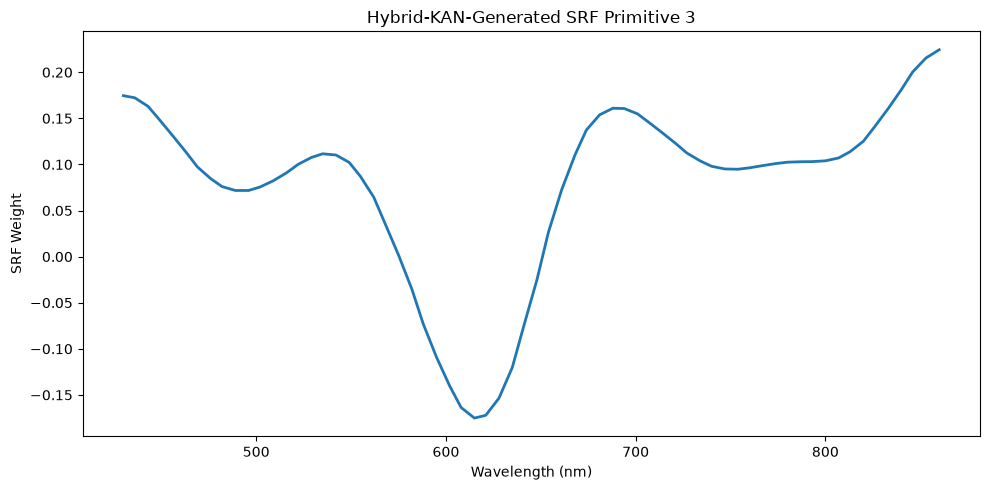

In [14]:
primitive_curves = []

model.eval()

for primitive_no in range(number_of_primitives):

    with torch.no_grad():

        curve = (
            model.primitives[primitive_no]
            .get_srf()
            .cpu()
            .numpy()
        )

    primitive_curves.append(curve)

    print(
        f"Primitive {primitive_no + 1} "
        f"SRF shape: {curve.shape}"
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        wavelength_int[:no_of_bands],
        curve,
        linewidth=2
    )

    plt.title(
        f"Hybrid-KAN-Generated SRF "
        f"Primitive {primitive_no + 1}"
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("SRF Weight")
    plt.tight_layout()
    plt.show()

In [15]:
for i ,p in enumerate(primitive_curves):
    print(i+1, f"primitive_{i+1}" , p[0])



1 primitive_1 -0.16994794
2 primitive_2 0.15059221
3 primitive_3 0.17461573


In [16]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.srf_generator.rbf_coefficients torch.Size([12])
1 primitives.0.srf_generator.base_coefficient torch.Size([1])
2 primitives.0.srf_generator.srf_offset torch.Size([1])
3 primitives.0.layernorm.weight torch.Size([66])
4 primitives.0.layernorm.bias torch.Size([66])
5 primitives.0.spline_linear.weight torch.Size([1, 528])
6 primitives.0.base_linear.weight torch.Size([1, 66])
7 primitives.0.base_linear.bias torch.Size([1])
8 primitives.1.srf_generator.rbf_coefficients torch.Size([12])
9 primitives.1.srf_generator.base_coefficient torch.Size([1])
10 primitives.1.srf_generator.srf_offset torch.Size([1])
11 primitives.1.layernorm.weight torch.Size([66])
12 primitives.1.layernorm.bias torch.Size([66])
13 primitives.1.spline_linear.weight torch.Size([1, 528])
14 primitives.1.base_linear.weight torch.Size([1, 66])
15 primitives.1.base_linear.bias torch.Size([1])
16 primitives.2.srf_generator.rbf_coefficients torch.Size([12])
17 primitives.2.srf_generator.base_coefficient torch.Size(

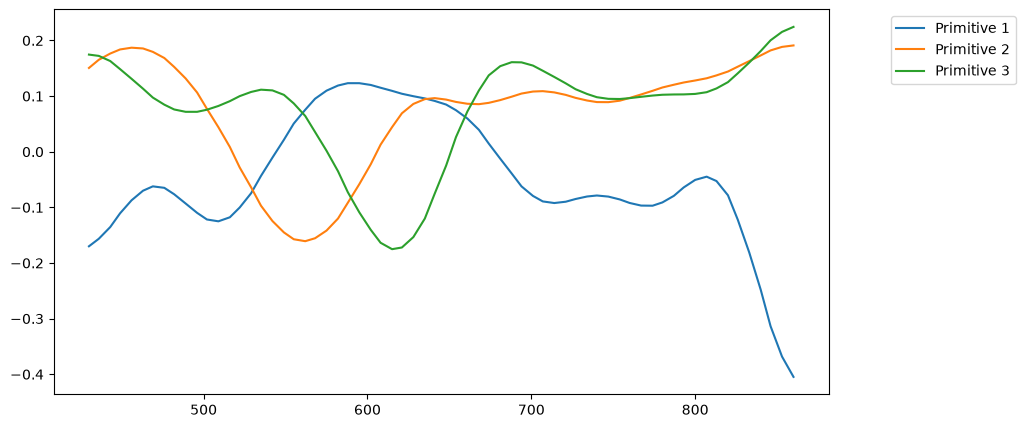

In [17]:

plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(wavelength_int[:no_of_bands],primitive_curves[primitive_no],label=f"Primitive {primitive_no + 1}")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()




In [18]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [19]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [20]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [22]:
model = HybridColorKAN(
    no_of_bands=no_of_bands,
    number_of_primitives=number_of_primitives,
    output_classes=output_classes,

    # Same values used while training
    wavelength_num_grids=12,
    intensity_num_grids=8,
    nonnegative_srf=False,
    use_base_update=True,
    spline_weight_init_scale=0.1
).to(device)


model.load_state_dict(
    torch.load(
        f"{model_name}.pth",
        weights_only=True
    )
)

model.eval()

HybridColorKAN(
  (primitives): ModuleList(
    (0-2): 3 x HybridSpectralPrimitive(
      (srf_generator): WavelengthSRFGenerator(
        (wavelength_rbf): GaussianRBF()
      )
      (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
      (intensity_rbf): GaussianRBF()
      (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
      (base_linear): Linear(in_features=66, out_features=1, bias=True)
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)

In [24]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = [primtive(x_pred) for primtive in model.primitives]
        prediction = torch.cat(primitive_outputs,dim=1)

    predicted_image = prediction.cpu().numpy().reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        global_max_image = predicted_image.copy()
    else:
        global_max_image = predicted_image / max_val

    signed_channelwise_image = np.zeros_like(predicted_image , dtype=np.float32)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max!= 0:
            signed_channelwise_image[:, :, i] = (
                channel / channel_max
            )
        else:
            signed_channelwise_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    channel_minmax_image = np.zeros_like(predicted_image , dtype=np.float32)
    for i in range(predicted_image.shape[-1]):
        channel = predicted_image[: , : , i]
        channel_min = np.min(channel)
        channel_max = np.max(channel)
        channel_minmax_image[: ,: ,i] = (channel -channel_min)/(channel_max -channel_min + 1e-8)
    c1 , c2 , c3 = [channel -1 for channel in channels]

    rgb_global_max = np.dstack((
        global_max_image[:, :, c1],
        global_max_image[:, :, c2],
        global_max_image[:, :, c3]
    ))

    rgb_signed_channelwise = np.dstack((
        signed_channelwise_image[:, :, c1],
        signed_channelwise_image[:, :, c2],
        signed_channelwise_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))
   
    return [
        rgb_global_max ,
        rgb_signed_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7818074..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


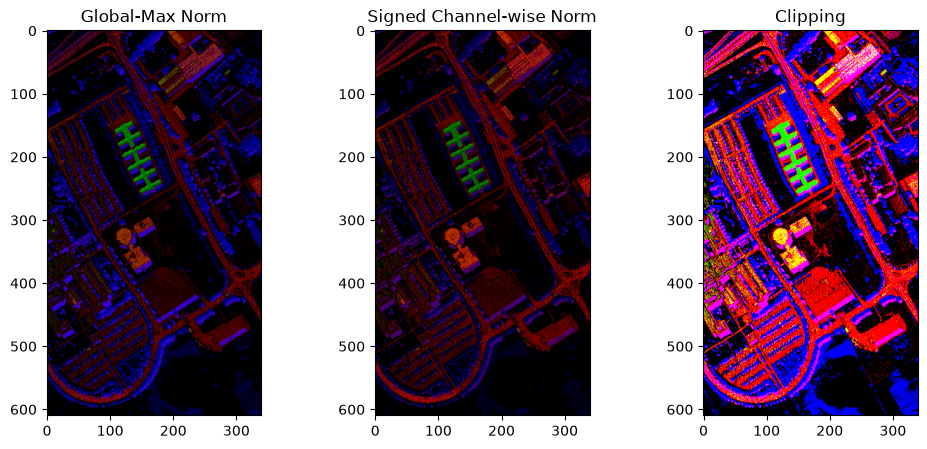

In [25]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Global-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Signed Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()